<a href="https://colab.research.google.com/github/atomicSteiner/HealthcareSBERT/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from scipy.stats import ttest_rel
from collections import Counter


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:

# =========================
# 1. Load Models
# =========================
# Baseline SBERT model
baseline_model = SentenceTransformer('all-MiniLM-L6-v2')

# Fine-tuned model (replace with your checkpoint path)
fine_tuned_model = SentenceTransformer('/content/drive/MyDrive/fine_tuned_sbert_ohsumed/fine_tuned_sbert_ohsumed')

# =========================
# 2. Load Data
# =========================
df = pd.read_csv("/content/drive/MyDrive/ohsumed_cleaned_test.csv")
texts = df['abstract'].tolist()
mesh_labels = df['mesh_terms'].tolist()

# =========================
# 3. Generate Embeddings
# =========================
if(not os.path.exists("/content/drive/MyDrive/embeddings_baseline.npy")):
  baseline_emb = baseline_model.encode(texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
else:
  baseline_emb = np.load("/content/drive/MyDrive/embeddings_baseline.npy")
if(not os.path.exists("/content/drive/MyDrive/fine_tuned_embeddings.npy")):
  finetuned_emb = fine_tuned_model.encode(texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
else:
  finetuned_emb = np.load("/content/drive/MyDrive/fine_tuned_embeddings.npy")

In [12]:
# ===============================================================
# 4. Dimensionality Reduction
# ===============================================================
print("=== Reducing Dimensions with PCA (50D) ===")
pca = PCA(n_components=50, random_state=42)
baseline_emb_pca = pca.fit_transform(baseline_emb)
finetuned_emb_pca = pca.transform(finetuned_emb)
print(f"PCA completed. Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}\n")

# ===============================================================
# 5. Clustering (KMeans)
# ===============================================================
k = 20  # choose based on silhouette/elbow
print(f"=== Performing KMeans clustering with k={k} ===")
kmeans_baseline = KMeans(n_clusters=k, random_state=42, verbose=0)
kmeans_finetuned = KMeans(n_clusters=k, random_state=42, verbose=0)

print("→ Fitting baseline embeddings...")
baseline_clusters = kmeans_baseline.fit_predict(baseline_emb_pca)
print("→ Fitting fine-tuned embeddings...")
finetuned_clusters = kmeans_finetuned.fit_predict(finetuned_emb_pca)
print("Clustering complete.\n")

=== Reducing Dimensions with PCA (50D) ===
PCA completed. Explained variance ratio: 0.6033

=== Performing KMeans clustering with k=20 ===
→ Fitting baseline embeddings...
→ Fitting fine-tuned embeddings...
Clustering complete.



In [14]:
import time
# ===============================================================
# 6. Evaluation Metrics (Verbose)
# ===============================================================
def cluster_purity(clusters, labels):
    total = 0
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        majority = pd.Series(np.array(labels)[idx]).value_counts().iloc[0]
        total += majority
    return total / len(labels)

def evaluate_verbose(name, embeddings, clusters, labels):
    print(f"\n=== Evaluating {name} Clusters ===")
    start = time.time()
    metrics = {}

    print("→ Computing Silhouette score...")
    metrics["silhouette"] = silhouette_score(embeddings, clusters)
    print(f"   ✓ Silhouette = {metrics['silhouette']:.4f}")

    print("→ Computing Davies–Bouldin index...")
    metrics["davies_bouldin"] = davies_bouldin_score(embeddings, clusters)
    print(f"   ✓ Davies–Bouldin = {metrics['davies_bouldin']:.4f}")

    print("→ Computing Adjusted Rand Index (ARI)...")
    metrics["ARI"] = adjusted_rand_score(labels, clusters)
    print(f"   ✓ ARI = {metrics['ARI']:.4f}")

    print("→ Computing Normalized Mutual Information (NMI)...")
    metrics["NMI"] = normalized_mutual_info_score(labels, clusters)
    print(f"   ✓ NMI = {metrics['NMI']:.4f}")

    print("→ Computing Cluster Purity...")
    metrics["purity"] = cluster_purity(clusters, labels)
    print(f"   ✓ Purity = {metrics['purity']:.4f}")

    print(f"✅ {name} evaluation completed in {(time.time()-start):.2f}s.\n")
    return metrics

baseline_metrics = evaluate_verbose("Baseline", baseline_emb_pca, baseline_clusters, mesh_labels)
finetuned_metrics = evaluate_verbose("Fine-tuned", finetuned_emb_pca, finetuned_clusters, mesh_labels)

print("=== Summary of Metrics ===")
print(pd.DataFrame([baseline_metrics, finetuned_metrics], index=["Baseline", "Fine-tuned"]))
print()



=== Evaluating Baseline Clusters ===
→ Computing Silhouette score...
   ✓ Silhouette = 0.0694
→ Computing Davies–Bouldin index...
   ✓ Davies–Bouldin = 2.7048
→ Computing Adjusted Rand Index (ARI)...
   ✓ ARI = 0.0000
→ Computing Normalized Mutual Information (NMI)...
   ✓ NMI = 0.3908
→ Computing Cluster Purity...
   ✓ Purity = 0.0002
✅ Baseline evaluation completed in 657.42s.


=== Evaluating Fine-tuned Clusters ===
→ Computing Silhouette score...
   ✓ Silhouette = 0.0650
→ Computing Davies–Bouldin index...
   ✓ Davies–Bouldin = 2.8136
→ Computing Adjusted Rand Index (ARI)...
   ✓ ARI = 0.0000
→ Computing Normalized Mutual Information (NMI)...
   ✓ NMI = 0.3913
→ Computing Cluster Purity...
   ✓ Purity = 0.0002
✅ Fine-tuned evaluation completed in 652.19s.

=== Summary of Metrics ===
            silhouette  davies_bouldin           ARI       NMI    purity
Baseline      0.069435        2.704764  4.565863e-08  0.390779  0.000158
Fine-tuned    0.065013        2.813622  2.851782e-08  0

In [15]:
from sklearn.metrics.pairwise import cosine_distances
# ===============================================================
# 7. Representative Example per Cluster
# ===============================================================
def show_cluster_examples(embeddings, clusters, texts, mesh_labels, top_n=1, model_name=""):
    print(f"\n=== Representative examples for {model_name} clusters ===")

    unique_clusters = np.unique(clusters)
    df_examples = []

    for cluster_id in unique_clusters:
        idxs = np.where(clusters == cluster_id)[0]
        cluster_embs = embeddings[idxs]
        centroid = cluster_embs.mean(axis=0, keepdims=True)
        dists = cosine_distances(cluster_embs, centroid).flatten()
        sorted_idx = idxs[np.argsort(dists)[:top_n]]

        for rank, i in enumerate(sorted_idx, 1):
            df_examples.append({
                "Cluster": cluster_id,
                "Rank": rank,
                "Text": texts[i][:300] + ("..." if len(texts[i]) > 300 else ""),
                "MeSH": mesh_labels[i]
            })

    df_out = pd.DataFrame(df_examples)
    display(df_out.sort_values(["Cluster", "Rank"]))
    print(f"✅ Displayed {len(unique_clusters)} clusters × top {top_n} examples.\n")

show_cluster_examples(baseline_emb_pca, baseline_clusters, texts, mesh_labels, top_n=1, model_name="Baseline")
show_cluster_examples(finetuned_emb_pca, finetuned_clusters, texts, mesh_labels, top_n=1, model_name="Fine-tuned")


=== Representative examples for Baseline clusters ===


,Cluster,Rank,Text,MeSH
0,0,1,A 61-year-old right-handed man with a history ...,Aphasia/*CO/ET; Case Report; Cerebrovascular D...
1,1,1,"The in vitro activity of PD 127,391, a dihalog...","Anti-Infective Agents, Quinolone/*PD; Bacteria..."
2,2,1,We reviewed the records of 20 consecutive eyes...,"Aged; Aged, 80 and over; Anterior Chamber; Cor..."
3,3,1,"In spontaneously hypertensive rats (SHR), the ...",Animal; Blood Pressure/DE; Blood Volume/DE; Bo...
4,4,1,Lot differences in the biopotency of human men...,Animal; Biological Assay; Cell Count; Chromato...
5,5,1,"Thirty-one patients with advanced, biopsy-prov...","Bleomycins/AD/*TU; Carcinoma, Squamous Cell/DT..."
6,6,1,To determine if diet composition influences re...,Adult; Body Composition/*/DE; Carbohydrates/ME...
7,7,1,BACKGROUND. Primary infection with the human i...,Acquired Immunodeficiency Syndrome/IM/*MI/PP; ...
8,8,1,The response of breathing patterns to increase...,"Adolescence; Adult; Anesthesia, Inhalation/*; ..."
9,9,1,Duodenal perforation resulting from endoscopic...,Adult; Aged; Duodenum/*IN; Female; Human; Inte...


✅ Displayed 20 clusters × top 1 examples.


=== Representative examples for Fine-tuned clusters ===


,Cluster,Rank,Text,MeSH
0,0,1,The management of carpal dislocation after a l...,Accidental Falls; Adult; Carpal Bones/*IN/RA/S...
1,1,1,We analyzed the mechanism by which accessory c...,"Adjuvants, Immunologic/PH; Antibodies, Monoclo..."
2,2,1,Testosterone (T) inhibits GnRH secretion and c...,Animal; Estradiol/*PD; FSH/BL/*GE; Glycoprotei...
3,3,1,This is a brief summary of the development of ...,Europe; Female; Forecasting; History of Medici...
4,4,1,The area of circadian rhythms and sleep alteri...,Asthma/BL/PP/TH; Circadian Rhythm; Human; Lung...
5,5,1,We describe changes in the anterior lens capsu...,"Adult; Aged; Aged, 80 and over; Climate/*; Cor..."
6,6,1,Various researchers have suggested that tradit...,Aged; Behavior/*; Female; Human; Male; Middle ...
7,7,1,Rhodes and Klug have recently proposed that th...,Animal; Base Composition; Binding Sites; Circu...
8,8,1,"Epidemiology, historically the study of commun...",Epidemiology/*; Family Practice/*; Human; Rese...
9,9,1,Two studies were performed to evaluate the sho...,Adult; Caloric Intake/*; Dietary Carbohydrates...


✅ Displayed 20 clusters × top 1 examples.



In [16]:
from tqdm import tqdm
# ===============================================================
# 8. Fast Bootstrap Significance Testing
# ===============================================================
import numpy as np
from scipy.stats import ttest_rel
from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans

print("\n=== Running Fast Bootstrap Significance Tests ===")

def fast_bootstrap_metrics(name, embeddings, labels, k=20, n_bootstrap=10, sample_frac=0.7):
    """
    Faster bootstrap: fewer iterations + smaller sample size + MiniBatchKMeans.
    """
    n_samples = len(labels)
    metrics_list = {"ARI": [], "NMI": [], "silhouette": []}
    print(f"→ {name}: {n_bootstrap} resamples, {int(sample_frac*100)}% of data each.")

    for i in tqdm(range(n_bootstrap), desc=f"{name} bootstrap"):
        idx = np.random.choice(n_samples, size=int(n_samples * sample_frac), replace=True)
        sample_emb = embeddings[idx]
        sample_labels = np.array(labels)[idx]

        # Faster clustering with MiniBatchKMeans
        km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256)
        clusters = km.fit_predict(sample_emb)

        # Compute quick metrics
        metrics_list["ARI"].append(adjusted_rand_score(sample_labels, clusters))
        metrics_list["NMI"].append(normalized_mutual_info_score(sample_labels, clusters))
        # Silhouette on small random subset for speed
        sub_idx = np.random.choice(len(sample_emb), size=min(1000, len(sample_emb)), replace=False)
        metrics_list["silhouette"].append(silhouette_score(sample_emb[sub_idx], clusters[sub_idx]))

    for key in metrics_list:
        metrics_list[key] = np.array(metrics_list[key])

    print(f"✅ {name} done: mean ARI={metrics_list['ARI'].mean():.4f}, "
          f"NMI={metrics_list['NMI'].mean():.4f}, "
          f"Silhouette={metrics_list['silhouette'].mean():.4f}\n")
    return metrics_list


# Run fast bootstrap
baseline_bootstrap = fast_bootstrap_metrics("Baseline", baseline_emb_pca, mesh_labels, k=k)
finetuned_bootstrap = fast_bootstrap_metrics("Fine-tuned", finetuned_emb_pca, mesh_labels, k=k)

# Paired t-test for statistical significance
print("=== Paired t-tests on fast bootstrap results ===")
for metric in ["ARI", "NMI", "silhouette"]:
    t_stat, p_val = ttest_rel(baseline_bootstrap[metric], finetuned_bootstrap[metric])
    print(f"{metric}: mean baseline={baseline_bootstrap[metric].mean():.4f}, "
          f"mean fine-tuned={finetuned_bootstrap[metric].mean():.4f}, p={p_val:.4f}")




=== Running Fast Bootstrap Significance Tests ===
→ Baseline: 10 resamples, 70% of data each.


Baseline bootstrap: 100%|██████████| 10/10 [01:04<00:00,  6.41s/it]


✅ Baseline done: mean ARI=0.0002, NMI=0.4124, Silhouette=0.0599

→ Fine-tuned: 10 resamples, 70% of data each.


Fine-tuned bootstrap: 100%|██████████| 10/10 [01:05<00:00,  6.54s/it]

✅ Fine-tuned done: mean ARI=0.0002, NMI=0.4117, Silhouette=0.0630

=== Paired t-tests on fast bootstrap results ===
ARI: mean baseline=0.0002, mean fine-tuned=0.0002, p=0.0802
NMI: mean baseline=0.4124, mean fine-tuned=0.4117, p=0.0787
silhouette: mean baseline=0.0599, mean fine-tuned=0.0630, p=0.0349


=== Step 8: Visualizing PCA Clusters ===

→ Reducing embeddings for Baseline Clusters
→ Plotting 2D scatter for Baseline Clusters


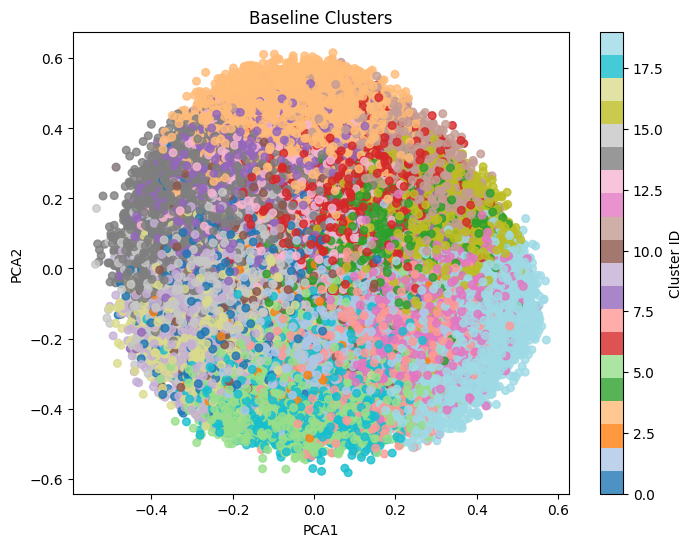

Finished visualization for Baseline Clusters


→ Reducing embeddings for Fine-tuned Clusters
→ Plotting 2D scatter for Fine-tuned Clusters


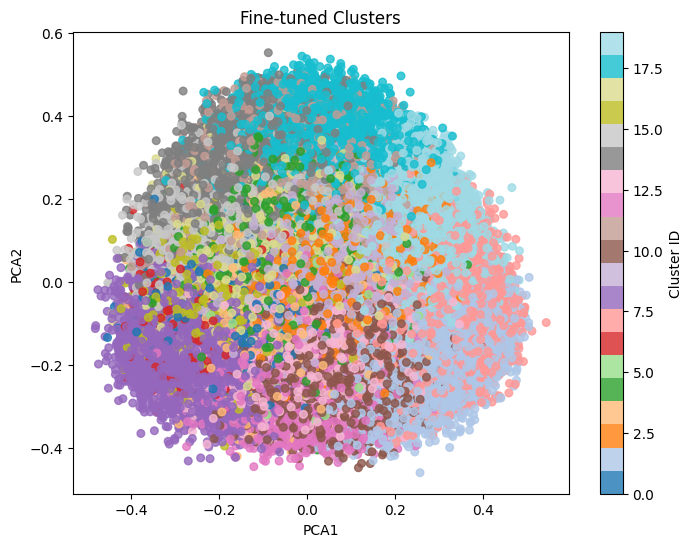

Finished visualization for Fine-tuned Clusters



In [17]:
import matplotlib.pyplot as plt
# ---------------------------
# Step 9 — Visualization
# ---------------------------
print("=== Step 8: Visualizing PCA Clusters ===")

def plot_pca_clusters_verbose(embeddings, clusters, title):
    print(f"\n→ Reducing embeddings for {title}")
    pca_2d = PCA(n_components=2)
    emb_2d = pca_2d.fit_transform(embeddings)

    print(f"→ Plotting 2D scatter for {title}")
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=clusters, cmap='tab20', s=30, alpha=0.8)
    plt.title(title)
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.colorbar(scatter, label='Cluster ID')
    plt.show()
    print(f"Finished visualization for {title}\n")

plot_pca_clusters_verbose(baseline_emb_pca, baseline_clusters, "Baseline Clusters")
plot_pca_clusters_verbose(finetuned_emb_pca, finetuned_clusters, "Fine-tuned Clusters")